In [1]:
from pygissim.pygissim import *
import pandas as pd
import pygissim.nb as nb
import matplotlib.pyplot as plt

from yfiles_jupyter_graphs import GraphWidget
from typing import Dict, Tuple

from tests.test_simulation import *
from tests.test_design import *


In [2]:
sim = TestSimulation.sample_simulator()
d = TestDesign.sample_design()

In [3]:
mobile = d.get_workflow('Mobile')
mobile.user_count = 50
web = d.get_workflow('Web')
web.tph = 4000

In [4]:
# nb.describe_workflow(mobile)
print(nb.describe_workflow(web))

Web () type: WorkflowType.TRANSACTIONAL 
	tph: 4000
	Web Map Definition (Sample Web Map):
	Layers:
		Dynamic Map Image ():
		Steps:
			Browser Client Step (Sample Browser Step) type: browser
				st: 20 ms; chatter: 10; size: 100/2134 kb; data: DataSourceType.NONE; cache: 20%
			Web Service Step (Sample Web Step) type: web
				st: 18 ms; chatter: 10; size: 100/2134 kb; data: DataSourceType.NONE; cache: 0%
			Portal Service Step (Sample Portal Step) type: portal
				st: 19 ms; chatter: 10; size: 100/2134 kb; data: DataSourceType.FILE; cache: 0%
			Dynamic Map Service Step (Sample Dynamic Map Step) type: map
				st: 141 ms; chatter: 10; size: 100/2134 kb; data: DataSourceType.DBMS; cache: 0%
			DBMS Service Step (Sample DBMS Step) type: dbms
				st: 24 ms; chatter: 500; size: 500/13340 kb; data: DataSourceType.FILE; cache: 75%
		Service Providers:
			Web browser () service: Browser; nodes: [Client 001]
			Pro workstation () service: Pro; nodes: [Client 001]
			IIS () service: Web; nodes: 

In [5]:
sim.design = d
sim.start()
sim.next_event_time()

162

In [6]:
for i in range(1,500):
    sim.advance_time_by(500)
    sim.gather_queue_metrics()

In [7]:
test = nb.util_stats_for_queues(sim.queue_metrics)
test

,Queue,Avg,p5,p50,p75,p95,p99
0,AGOL to AGOL,0.004994,0.004000,0.005000,0.005000,0.006000,0.007000
1,AGOL to Internet,0.084864,0.068000,0.085000,0.090500,0.102000,0.117040
2,AGOL01,0.501494,0.420300,0.497000,0.534000,0.601700,0.644280
3,Client 001,0.000179,0.000080,0.000160,0.000240,0.000320,0.000344
4,DMZ to DMZ,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,DMZ to Internet,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,DMZ to Local,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,Internet to AGOL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,Internet to DMZ,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,Internet to Internet,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [8]:
test_r = nb.perf_stats_for_requests(sim.request_metrics)
# sim.request_metrics
test_r

,Workflow,Count,QT_Min,QT_Max,QT_Avg,Net_Avg,Lat_Avg,ST_Avg,RT_Avg,RT_p5,RT_p50,RT_p75,RT_p95,RT_p99
0,Mobile,2491,0,0,0.000000,18.000000,300.0,607.702529,925.702529,679.0,679.0,1173.0,1173.0,1173.0
1,Web,557,0,11,0.043088,44.481149,0.0,936.098743,980.622980,469.0,480.0,1494.0,1494.0,1494.0


In [9]:

def draw_queue_utilization(df: pd.DataFrame, rolling: bool = False):
    min_val = 0.0
    max_val = 1.0
    
    for col in df.columns:
        if col == 'Clock': continue;
        df[col] = pd.to_numeric(df[col])
        if rolling:
            df[col] = df[col].rolling(3).mean()
        max_val = max(max_val, df[col].max())

    fig, ax = plt.subplots(figsize=(15,7))
    ax.grid(True)
    plt.xlim(df.index.min(), df.index.max())
    plt.ylim(min_val, max_val)

    for col in df.columns:
        if col == 'Clock': continue;
        plt.plot(df.index, df[col], label=col, linewidth=0.75)#, color=SERIES_INFO[vm]['color'])

    plt.legend(loc='upper left')
    plt.title('Utilization')
    plt.show()
    # q_util.plot(x='Clock', y='Utilization', kind='line')


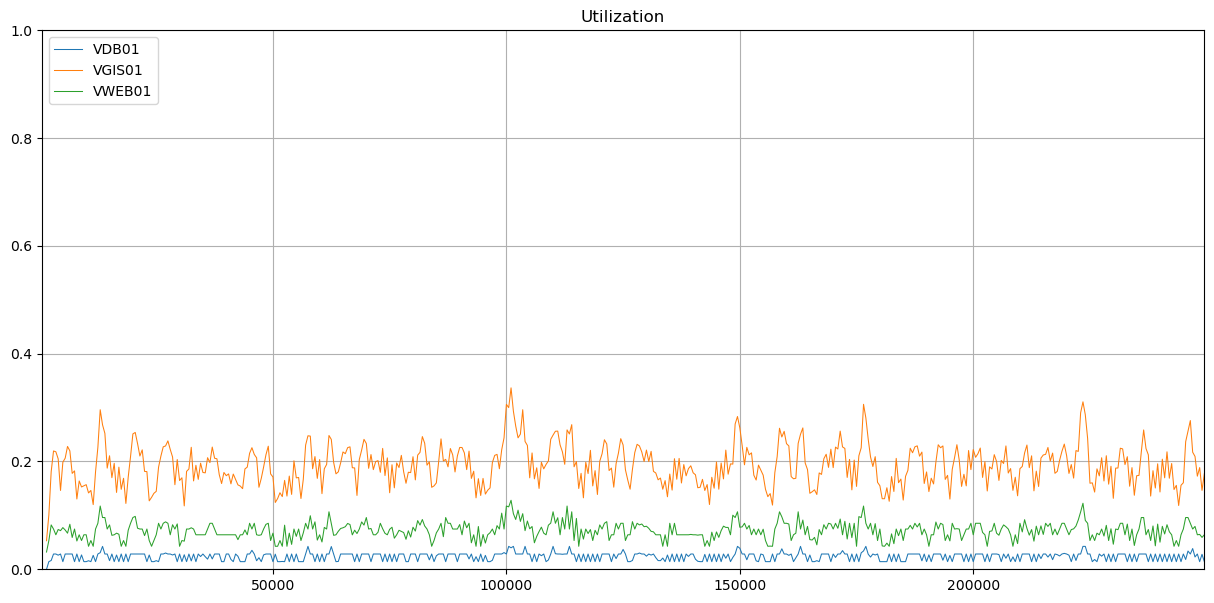

In [10]:
q_util = nb.utilization_for_queues(sim.queue_metrics, queue_type='V_SERVER')
draw_queue_utilization(q_util, rolling=True)

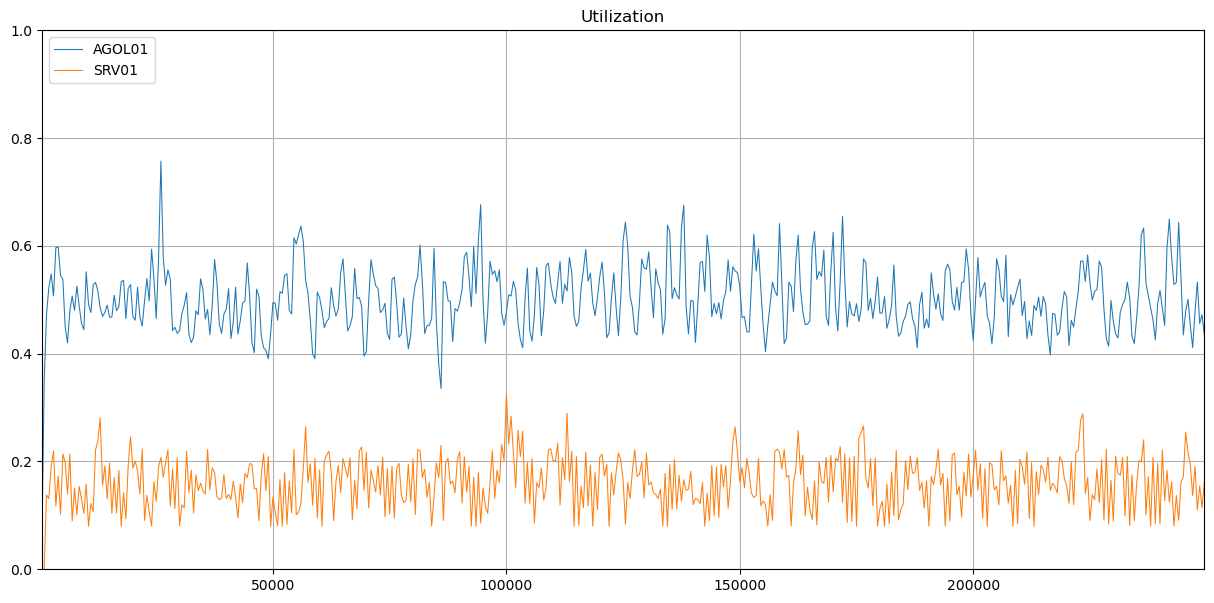

In [11]:
q_util = nb.utilization_for_queues(sim.queue_metrics, queue_type='P_SERVER')
draw_queue_utilization(q_util)

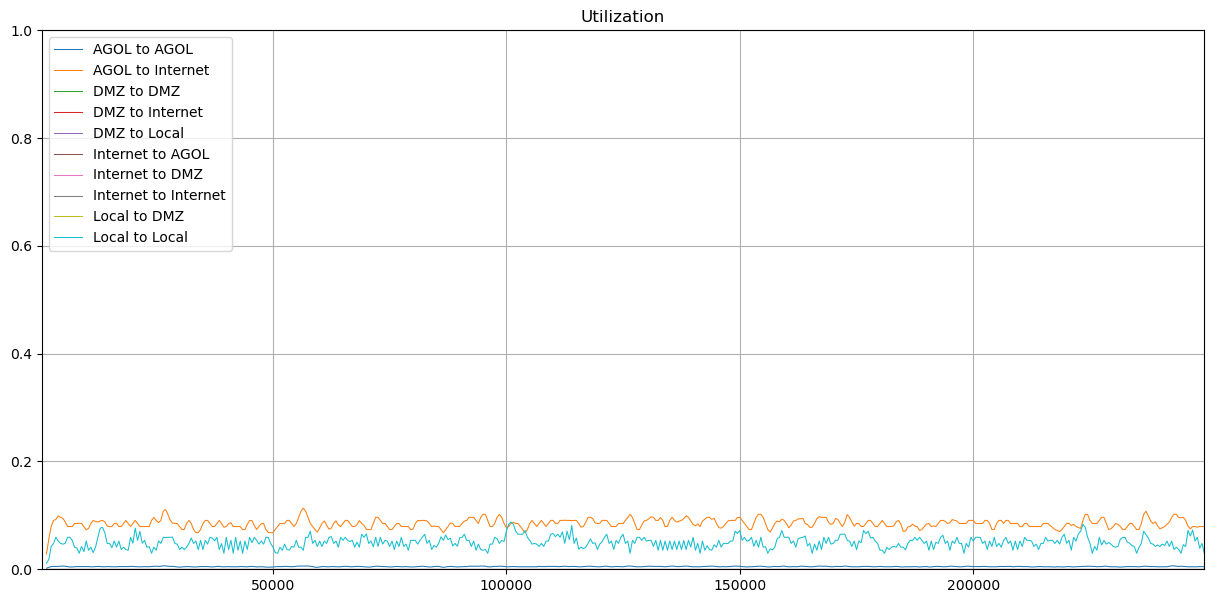

In [12]:
q_util = nb.utilization_for_queues(sim.queue_metrics, queue_type='CONNECTION')
draw_queue_utilization(q_util, rolling=True)

In [17]:
def zones_to_nodes(zones: list[Zone]):
    nodes = []
    for zone in zones:
        nodes.append({"id": zone.id, 
                      "properties":{'label': zone.name}}) #, 'type': str(zone.type)
    return nodes

def connections_to_edges(net: list[Connection]):
    edges = []
    util_stats = nb.util_stats_for_queues(sim.queue_metrics, queue_type='CONNECTION')
    for conn in net:
        conn_stats = util_stats[util_stats['Queue'] == conn.name].reset_index(drop=True)
        avg = conn_stats.at[0, 'Avg']
        edges.append({"id": conn.name, 'start': conn.source.id, 'end': conn.destination.id, 
                      "properties":{'name': conn.name, 'label': conn.bandwidth, 'lat': conn.latency_ms, 'util': avg}})
    return edges

In [18]:
def workflows_nodes_edges(workflows: list[Workflow]) -> Tuple[list,list]:
    nodes = []
    edges = []

    for w in workflows:
        nodes.append({"id": w.name, "properties":{'label': w.name, 'type': 'Workflow'}})
        wdef = w.definition
        nodes.append({"id": wdef.name, "properties":{'label': wdef.name, 'type': 'Definition'}})
        edges.append({"id": f'{w.name}-{wdef.name}', "start": w.name, "end": wdef.name, 'properties': {'wf': w.name}})
        for chain in wdef.chains:
            nodes.append({"id": chain.name, "properties":{'label': chain.name, 'type': 'Chain'}})
            edges.append({"id": f'{wdef.name}-{chain.name}', "start": wdef.name, "end": chain.name, 'properties': {'wf': w.name}})
            if len(chain.steps) == 0: continue
            nodes.append({"id": f'{chain.name}-{chain.steps[0].name}', "properties":{'label': chain.steps[0].name, 'type': 'Step'}})
            edges.append({"id": f'{chain.name}-{nodes[-1]['id']}', "start": chain.name, "end": nodes[-1]['id'], 'properties': {'wf': w.name}})
            for i in range(1, len(chain.steps)):
                nodes.append({"id": f'{chain.name}-{chain.steps[i].name}', "properties":{'label': chain.steps[i].name, 'type': 'Step'}})
                edges.append({"id": f'{nodes[-2]['id']}-{nodes[-1]['id']}', "start": nodes[-2]['id'], "end": nodes[-1]['id'], 'properties': {'wf': w.name}})

    # Eliminate duplicate nodes
    n_dict = dict()
    for node in nodes: n_dict[node['id']] = node
    nodes = list(n_dict.values())
    
    return (nodes,edges)


In [19]:
def network_node_color_mapping(node: Dict) -> str:
    match node['properties']['type']:
        case 'ZoneType.LOCAL': return '#9999FF'
        case 'ZoneType.EDGE': return '#FF9911'
        case 'ZoneType.INTERNET': return '#DDDDDD'
        case _: '#000000'

def network_edge_color_mapping(edge: Dict) -> str:
    util: float = edge['properties']['util']
    if util < .01: return '#CCCCCC'
    elif util < .10: return '#0000FF'
    elif util < .25: return '#00FF00'
    elif util < 0.5: return '#DDDD00'
    elif util < 0.9: return '#FFA500'
    else: return '#FF0000'


In [20]:
w = GraphWidget()
w.nodes = zones_to_nodes(sim.design.zones)
w.edges = connections_to_edges(sim.design.network)
w.directed = True
w.graph_layout = 'orthogonal'
w.set_node_color_mapping(network_node_color_mapping)
w.set_edge_color_mapping(network_edge_color_mapping)
# w.set_edge_thickness_mapping(edge_thickness_mapping)

w.show()

Exception: Could not resolve the mapping function for the given data object 
 { 
 	 {'id': 'eb2b2844-0c55-11f1-8741-5a6462228a4e', 'properties': {'label': 'AGOL'}} 
 } 
 

In [ ]:
def wf_node_color_mapping(node: Dict) -> str:
    match node['properties']['type']:
        case 'Workflow': return '#9999FF'
        case 'Definition': return '#FF9911'
        case 'Chain': return '#DDDDDD'
        case 'Step': return '#999999'
        case _: return '#FFFFFF'

def wf_edge_color_mapping(edge: Dict) -> str:
    match edge['properties']['wf']:
        case 'Web': return '#0000FF'
        case 'Mobile': return '#00FF00'
        case _: return '#333333'


In [ ]:
w = GraphWidget()
nodes_edges = workflows_nodes_edges(sim.design.all_workflows())
w.nodes = nodes_edges[0]
w.edges = nodes_edges[1]
w.graph_layout = 'hierarchic'
w.set_node_color_mapping(wf_node_color_mapping)
w.set_edge_color_mapping(wf_edge_color_mapping)
w.show()